In [1]:
import numpy as np, pandas as pd
from sim_theorem_partii import sin2_angle_to_axis

SEED = 20260717
k = 3

sigma = np.array([0.16, 0.08, 0.06])      # factor vols
c     = np.array([1.25, 1.0, 1.0])         # prevalences
Chalf = np.diag(np.sqrt(c))
n, N_REPS = 63, 100_000
rng = np.random.default_rng(SEED)

sin2 = np.empty((N_REPS, k))
for r in range(N_REPS):
    F = rng.standard_t(6, size=(n, k)) / np.sqrt(1.5) * sigma
    Dhat = Chalf @ (F.T @ F / n) @ Chalf
    vals, vecs = np.linalg.eigh(Dhat)   # ascending
    W = vecs[:, ::-1]                    # reverse columns -> factor 1,2,3
    sin2[r] = sin2_angle_to_axis(W)

q = np.quantile(sin2, [0.50, 0.80, 0.95], axis=0)   # shape (3 quantiles, 3 factors)
pd.DataFrame(q, index=["q50", "q80", "q95"],
                columns=["factor 1", "factor 2", "factor 3"])

,factor 1,factor 2,factor 3
q50,0.004838,0.030781,0.025766
q80,0.012612,0.122750,0.118759
q95,0.027672,0.546264,0.545881


In [2]:
def rotation_sin2_rep(n, rng, dist="t6"):
    if dist == "t6":
        F = rng.standard_t(6, size=(n, k)) / np.sqrt(1.5) * sigma
    else:  # "normal"
        F = rng.standard_normal(size=(n, k)) * sigma
    Dhat = Chalf @ (F.T @ F / n) @ Chalf
    vals, vecs = np.linalg.eigh(Dhat)
    W = vecs[:, ::-1]
    return sin2_angle_to_axis(W)

In [3]:
N_VALUES = [20, 42, 63, 126, 189, 252]   # ~1 month to ~1 year of daily data
q_levels = [0.50, 0.80, 0.95]

rows = []
for dist in ["t6", "normal"]:
    for nv in N_VALUES:
        rng_n = np.random.default_rng(SEED + nv)
        s = np.array([rotation_sin2_rep(nv, rng_n, dist) for _ in range(N_REPS)])
        for lvl in q_levels:
            qv = np.quantile(s, lvl, axis=0)
            for j in range(k):
                rows.append({"dist": dist, "n": nv, "quantile": lvl,
                             "factor": j+1, "rotation_sin2": qv[j]})

tbl = pd.DataFrame(rows)
tbl.to_csv("nb_outputs/ex4_rotation_quantiles.csv", index=False)
tbl[tbl["quantile"] == 0.95].pivot_table(index=["factor","n"], columns="dist", values="rotation_sin2")

dist          normal        t6
factor n                      
1      20   0.087163  0.129424
       42   0.037296  0.045982
       63   0.023825  0.027791
       126  0.011717  0.012656
       189  0.007689  0.008106
       252  0.005653  0.005969
2      20   0.790887  0.946685
       42   0.407566  0.785657
       63   0.248204  0.550188
       126  0.105545  0.183653
       189  0.067824  0.097789
       252  0.049098  0.064910
3      20   0.787203  0.943396
       42   0.405246  0.782979
       63   0.245563  0.548806
       126  0.104236  0.182607
       189  0.067040  0.097029
       252  0.048408  0.064338

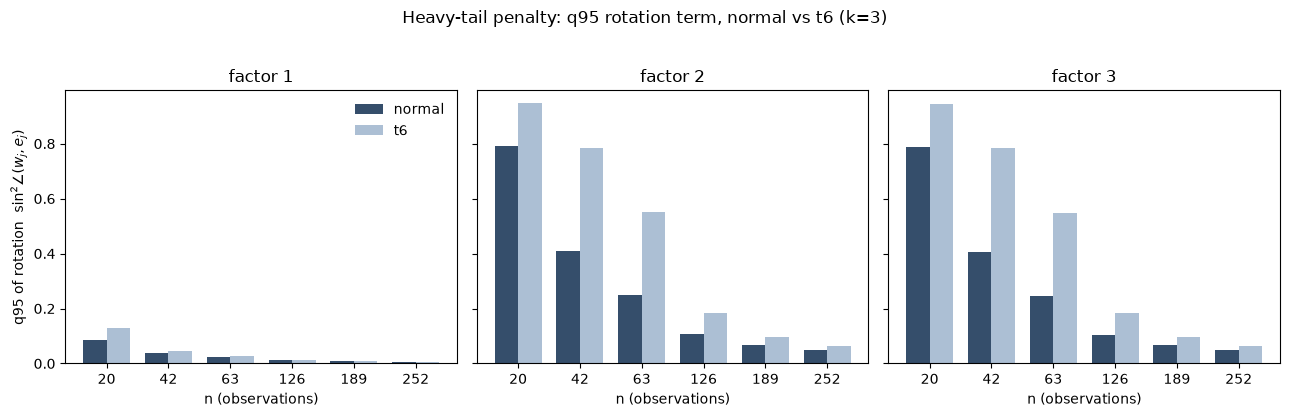

In [4]:
import matplotlib.pyplot as plt
NORMAL, T6 = "#354E6B", "#ACBFD4"
q95 = tbl[tbl["quantile"] == 0.95]

x = np.arange(len(N_VALUES)); w = 0.38
fig, axes = plt.subplots(1, k, figsize=(13, 4), sharey=True)
for ax, j in zip(axes, range(1, k+1)):
    sub = q95[q95["factor"] == j].set_index(["dist", "n"])["rotation_sin2"]
    ax.bar(x - w/2, [sub[("normal", nv)] for nv in N_VALUES], w, label="normal", color=NORMAL)
    ax.bar(x + w/2, [sub[("t6",     nv)] for nv in N_VALUES], w, label="t6",     color=T6)
    ax.set_title(f"factor {j}"); ax.set_xticks(x); ax.set_xticklabels(N_VALUES)
    ax.set_xlabel("n (observations)")
axes[0].set_ylabel(r"q95 of rotation  sin$^2\angle(w_j, e_j)$")
axes[0].legend(frameon=False)
fig.suptitle("Heavy-tail penalty: q95 rotation term, normal vs t6 (k=3)", y=1.03)
fig.tight_layout()
fig.savefig("nb_outputs/ex4_rotation_bars.png", dpi=200, bbox_inches="tight")
plt.show()